## Grid Hunter Game

#### 1: Import Libraries & Global Configuration

In [2]:
!pip install ipycanvas ipywidgets ipyevents numpy matplotlib

In [3]:
# Import Core Libraries
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import os
from ipycanvas import Canvas, hold_canvas
from ipywidgets import Label, Button, HBox, VBox, Layout
from IPython.display import clear_output, display

# Global Configuration
# Game Grid
GRID_SIZE = 10
CELL_SIZE = 60
CANVAS_WIDTH = GRID_SIZE * CELL_SIZE
CANVAS_HEIGHT = GRID_SIZE * CELL_SIZE + 100

# Action Mapping
ACTION_UP = 0
ACTION_DOWN = 1
ACTION_LEFT = 2
ACTION_RIGHT = 3
ACTION_NAME = ["UP", "DOWN", "LEFT", "RIGHT"]

# Fixed Obstacle Positions
FIXED_OBSTACLES = [[1,1], [2,3], [4,5], [6,2], [7,7], [8,4], [3,8]]

# Q-Learning Hyperparameters
LEARNING_RATE = 0.1
DISCOUNT_FACTOR = 0.95
INITIAL_EPSILON = 1.0
EPSILON_DECAY = 0.999
MIN_EPSILON = 0.01
TRAIN_EPISODES = 3000

#### 2: Game Environment Class

In [4]:
class GridHunterEnv:
    def __init__(self):
        self.grid_size = GRID_SIZE
        self.fixed_obstacles = FIXED_OBSTACLES
        self.reset()
    
    def reset(self):
        self.agent_pos = [0, 0]
        self.stars = []
        self.gems = []
        self.obstacles = self.fixed_obstacles.copy()
        self.traps = []
        self.step_count = 0
        self.agent_score = 0
        self.done = False
        self.last_reward = 0
        self.last_action = -1
        self.last_distance_to_item = 0
        
        self.spawn_items()
        self.refresh_traps()
        self.last_distance_to_item = self.get_distance_to_nearest_item(self.agent_pos)
        return self.get_agent_state()
    
    def spawn_items(self):
        self.stars = []
        self.gems = []
        while len(self.stars) < 3:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos:
                continue
            if pos in self.obstacles or pos in self.traps or pos in self.stars or pos in self.gems:
                continue
            self.stars.append(pos)
        while len(self.gems) < 1:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos:
                continue
            if pos in self.obstacles or pos in self.traps or pos in self.stars or pos in self.gems:
                continue
            self.gems.append(pos)
    
    def refresh_traps(self):
        self.traps = []
        while len(self.traps) < 2:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos:
                continue
            if pos in self.obstacles or pos in self.stars or pos in self.gems or pos in self.traps:
                continue
            self.traps.append(pos)

    def get_distance_to_nearest_item(self, agent_pos):
        all_items = self.stars + self.gems
        if not all_items:
            return 999
        distances = [abs(pos[0]-agent_pos[0]) + abs(pos[1]-agent_pos[1]) for pos in all_items]
        return min(distances)
    
    def get_nearest_item(self):
        all_items = self.stars + self.gems
        if not all_items:
            return [self.grid_size//2, self.grid_size//2]
        distances = [abs(pos[0]-self.agent_pos[0]) + abs(pos[1]-self.agent_pos[1]) for pos in all_items]
        return all_items[distances.index(min(distances))]

    def get_valid_actions(self, pos):
        valid_actions = []
        if pos[0] > 0:
            valid_actions.append(ACTION_UP)
        if pos[0] < self.grid_size - 1:
            valid_actions.append(ACTION_DOWN)
        if pos[1] > 0:
            valid_actions.append(ACTION_LEFT)
        if pos[1] < self.grid_size - 1:
            valid_actions.append(ACTION_RIGHT)
        return valid_actions

    def get_agent_state(self):
        nearest_item = self.get_nearest_item()
        dx = nearest_item[0] - self.agent_pos[0]
        dy = nearest_item[1] - self.agent_pos[1]
        return (
            self.agent_pos[0],
            self.agent_pos[1],
            dx + 10,
            dy + 10
        )

    def step(self, action):
        current_pos = self.agent_pos.copy()
        new_pos = current_pos.copy()
        reward = 0

        if action == ACTION_UP:
            new_pos[0] -= 1
        elif action == ACTION_DOWN:
            new_pos[0] += 1
        elif action == ACTION_LEFT:
            new_pos[1] -= 1
        elif action == ACTION_RIGHT:
            new_pos[1] += 1

        if new_pos[0] < 0 or new_pos[0] >= self.grid_size or new_pos[1] < 0 or new_pos[1] >= self.grid_size:
            reward -= 2
            new_pos = current_pos.copy()
        elif new_pos in self.obstacles or new_pos in self.traps:
            reward -= 10
            new_pos = current_pos.copy()
        else:
            reward -= 0.05
            if new_pos in self.stars:
                reward += 15
                self.stars.remove(new_pos)
                self.agent_score += 1
                self.spawn_items()
            elif new_pos in self.gems:
                reward += 40
                self.gems.remove(new_pos)
                self.agent_score += 3
                self.spawn_items()

        current_distance = self.get_distance_to_nearest_item(new_pos)
        if current_distance < self.last_distance_to_item:
            reward += 0.5
        elif current_distance > self.last_distance_to_item:
            reward -= 0.2
        self.last_distance_to_item = current_distance
        self.agent_pos = new_pos
        self.last_action = action
        self.last_reward = reward
        self.step_count += 1

        if self.step_count % 10 == 0:
            self.refresh_traps()

        if self.step_count >= 300:
            self.done = True

        return self.get_agent_state(), reward, self.done

    def render(self):
        clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 9))
        
        ax.set_xlim(0, self.grid_size)
        ax.set_ylim(0, self.grid_size)
        ax.set_xticks(np.arange(0, self.grid_size+1, 1))
        ax.set_yticks(np.arange(0, self.grid_size+1, 1))
        ax.grid(True, color="gray", linewidth=2)
        ax.invert_yaxis()
        ax.set_xticklabels([])
        ax.set_yticklabels([])

        for pos in self.obstacles:
            ax.add_patch(plt.Rectangle((pos[1], pos[0]), 1, 1, color="black", label="Obstacle/Trap" if pos == self.obstacles[0] else ""))
        for pos in self.traps:
            ax.add_patch(plt.Rectangle((pos[1], pos[0]), 1, 1, color="orange"))
        for pos in self.stars:
            ax.add_patch(plt.Circle((pos[1]+0.5, pos[0]+0.5), 0.3, color="gold", label="Star (+15)" if pos == self.stars[0] else ""))
        for pos in self.gems:
            ax.add_patch(plt.Circle((pos[1]+0.5, pos[0]+0.5), 0.35, color="darkblue", label="Gem (+40)" if pos == self.gems[0] else ""))
        
        ax.add_patch(plt.Rectangle((self.agent_pos[1]+0.05, self.agent_pos[0]+0.05), 0.9, 0.9, color="red", ec="black", lw=2))
        ax.text(self.agent_pos[1]+0.5, self.agent_pos[0]+0.5, "A", fontsize=20, ha="center", va="center", color="white", weight="bold")

        action_name = ACTION_NAME[self.last_action] if self.last_action != -1 else "None"
        plt.title(
            f"Grid Hunter Game | Step {self.step_count}\n"
            f"Last Action: {action_name} | Last Reward: {self.last_reward:.2f}\n"
            f"Total Score: {self.agent_score}",
            fontsize=15
        )
        ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1), fontsize=12)
        plt.tight_layout()
        plt.show()

#### 3: Q-Learning Agent Class

In [5]:
class QLearningAgent:
    def __init__(self):
        self.epsilon = INITIAL_EPSILON
        self.lr = LEARNING_RATE
        self.gamma = DISCOUNT_FACTOR
        self.q_table = np.zeros((GRID_SIZE, GRID_SIZE, 21, 21, 4))
        print(f"Q-table initialized, shape: {self.q_table.shape}")

    def choose_action(self, state, valid_actions):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(valid_actions)
        else:
            q_values = self.q_table[state]
            valid_q = q_values[valid_actions]
            best_action_idx = np.argmax(valid_q)
            return valid_actions[best_action_idx]

    def update_q_table(self, state, action, reward, next_state, next_valid_actions):
        current_q = self.q_table[state][action]
        next_max_q = np.max(self.q_table[next_state][next_valid_actions])
        new_q = current_q + self.lr * (reward + self.gamma * next_max_q - current_q)
        self.q_table[state][action] = new_q

    def decay_epsilon(self):
        self.epsilon = max(MIN_EPSILON, self.epsilon * EPSILON_DECAY)

    def save_model(self, path="grid_hunter_q_table_fixed.npy"):
        np.save(path, self.q_table)
        print(f"Model saved to: {path}")

    def load_model(self, path="grid_hunter_q_table_fixed.npy"):
        if os.path.exists(path):
            self.q_table = np.load(path)
            self.epsilon = MIN_EPSILON
            print(f"Model loaded from: {path}")
            return True
        else:
            print(f"Model file not found: {path}")
            return False

#### 4: Training & Convergence Visualization

Q-table initialized, shape: (10, 10, 21, 21, 4)
=== Start Training for 3000 Episodes ===
Episode 300/3000 | Epsilon: 0.7407 | Avg Reward: -34.76 | Avg Score: 15.74
Episode 600/3000 | Epsilon: 0.5486 | Avg Reward: 296.74 | Avg Score: 34.20
Episode 900/3000 | Epsilon: 0.4064 | Avg Reward: 589.18 | Avg Score: 52.75
Episode 1200/3000 | Epsilon: 0.3010 | Avg Reward: 779.33 | Avg Score: 64.51
Episode 1500/3000 | Epsilon: 0.2230 | Avg Reward: 958.55 | Avg Score: 76.64
Episode 1800/3000 | Epsilon: 0.1652 | Avg Reward: 1060.69 | Avg Score: 83.64
Episode 2100/3000 | Epsilon: 0.1223 | Avg Reward: 1103.00 | Avg Score: 87.11
Episode 2400/3000 | Epsilon: 0.0906 | Avg Reward: 1214.80 | Avg Score: 93.98
Episode 2700/3000 | Epsilon: 0.0671 | Avg Reward: 1223.02 | Avg Score: 95.50
Episode 3000/3000 | Epsilon: 0.0497 | Avg Reward: 1244.35 | Avg Score: 98.13
Model saved to: grid_hunter_q_table_fixed.npy
=== Training Completed ===


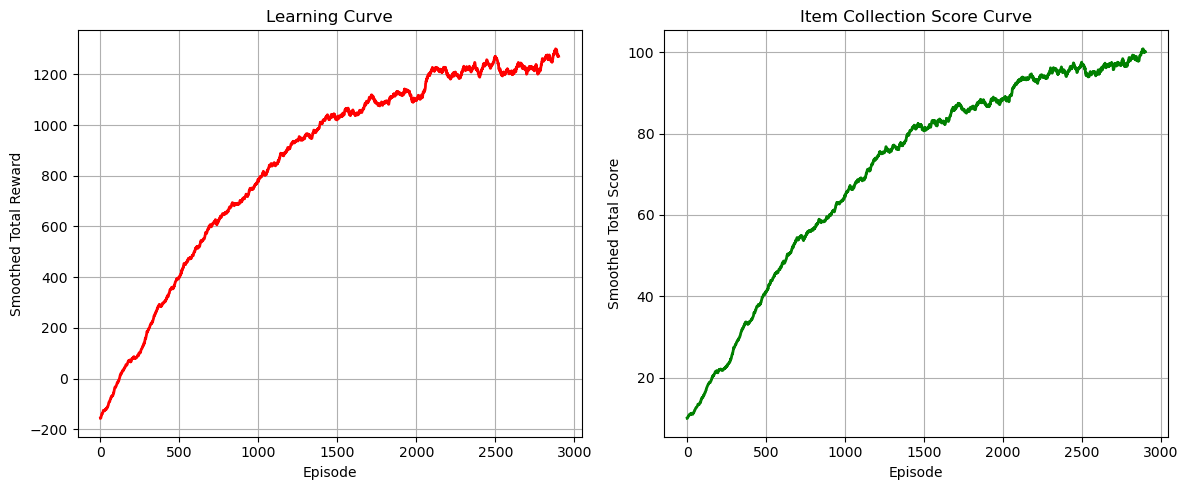

In [6]:
def train_agent():
    env = GridHunterEnv()
    agent = QLearningAgent()
    
    episode_rewards = []
    episode_scores = []
    epsilon_history = []

    print(f"=== Start Training for {TRAIN_EPISODES} Episodes ===")
    for episode in range(TRAIN_EPISODES):
        state = env.reset()
        total_reward = 0
        done = False

        while not done:
            valid_actions = env.get_valid_actions(env.agent_pos)
            action = agent.choose_action(state, valid_actions)
            next_state, reward, done = env.step(action)
            next_valid_actions = env.get_valid_actions(env.agent_pos)
            
            agent.update_q_table(state, action, reward, next_state, next_valid_actions)
            
            state = next_state
            total_reward += reward

        agent.decay_epsilon()
        episode_rewards.append(total_reward)
        episode_scores.append(env.agent_score)
        epsilon_history.append(agent.epsilon)
        
        if (episode + 1) % 300 == 0:
            avg_reward = np.mean(episode_rewards[-300:])
            avg_score = np.mean(episode_scores[-300:])
            print(f"Episode {episode+1}/{TRAIN_EPISODES} | Epsilon: {agent.epsilon:.4f} | Avg Reward: {avg_reward:.2f} | Avg Score: {avg_score:.2f}")

    agent.save_model()
    print("=== Training Completed ===")

    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    smoothed_rewards = np.convolve(episode_rewards, np.ones(100)/100, mode="valid")
    plt.plot(smoothed_rewards, color="red", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Total Reward")
    plt.title("Learning Curve")
    plt.grid(True)

    plt.subplot(1, 2, 2)
    smoothed_scores = np.convolve(episode_scores, np.ones(100)/100, mode="valid")
    plt.plot(smoothed_scores, color="green", linewidth=2)
    plt.xlabel("Episode")
    plt.ylabel("Smoothed Total Score")
    plt.title("Item Collection Score Curve")
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    plt.close('all')

    return agent, env, episode_rewards

# Run Training
trained_agent, train_env, reward_history = train_agent()

#### 5: AI Autoplay Demo

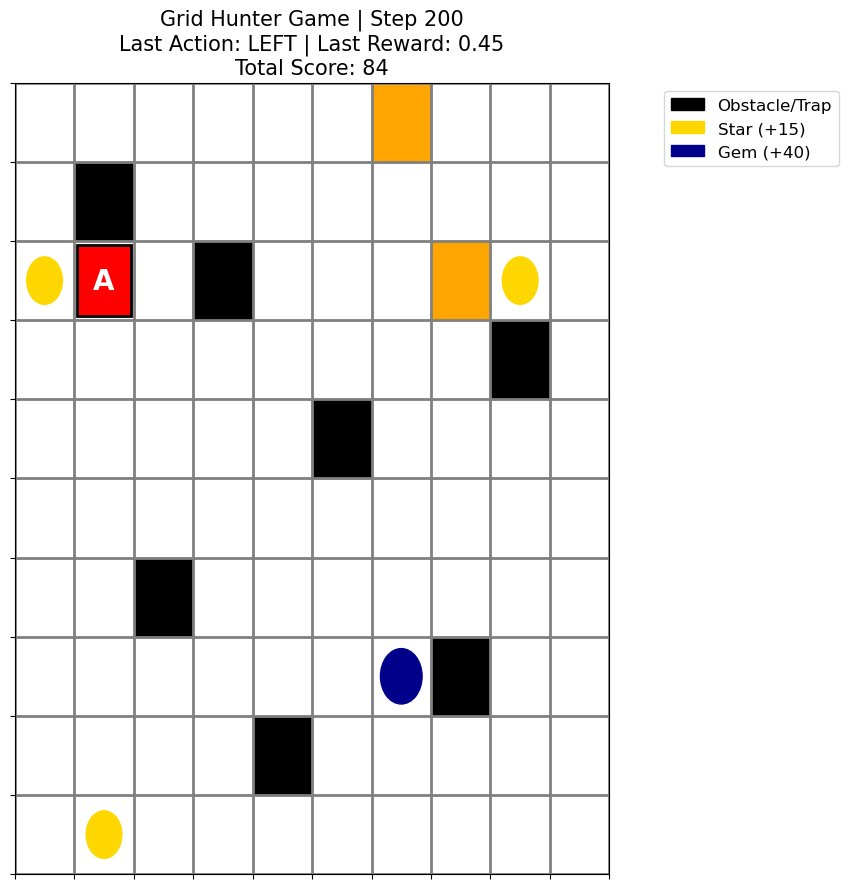

Demo Completed
Total Steps: 200 | Final Score: 84 | Total Reward: 1122.25


In [9]:
def run_ai_demo(agent, max_steps=200):
    env = GridHunterEnv()
    state = env.reset()
    agent.load_model()
    step = 0
    total_reward = 0
    
    print("AI Demo Start")
    while not env.done and step < max_steps:
        valid_actions = env.get_valid_actions(env.agent_pos)
        action = agent.choose_action(state, valid_actions)
        next_state, reward, done = env.step(action)
        
        state = next_state
        total_reward += reward
        step += 1
        
        env.render()
        time.sleep(0.3)
        plt.close('all')
    
    print(f"Demo Completed")
    print(f"Total Steps: {step} | Final Score: {env.agent_score} | Total Reward: {total_reward:.2f}")

# Run AI Demo
run_ai_demo(trained_agent)

#### 6：Human vs AI (Button Controls, Full Game)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import random
import time
import os
from ipywidgets import Label, Button, HBox, VBox, Layout, Output
from IPython.display import display, clear_output


GRID_SIZE = 10
ACTION_UP = 0
ACTION_DOWN = 1
ACTION_LEFT = 2
ACTION_RIGHT = 3
ACTION_NAME = ["UP", "DOWN", "LEFT", "RIGHT"]
FIXED_OBSTACLES = [[1,1], [2,3], [4,5], [6,2], [7,7], [8,4], [3,8]]

class QLearningAgent:
    def __init__(self):
        self.epsilon = 0.01
        self.lr = 0.1
        self.gamma = 0.95
        self.q_table = np.zeros((GRID_SIZE, GRID_SIZE, 21, 21, 4))

    def choose_action(self, state, valid_actions):
        if random.uniform(0, 1) < self.epsilon:
            return random.choice(valid_actions)
        else:
            q_values = self.q_table[state]
            valid_q = q_values[valid_actions]
            best_action_idx = np.argmax(valid_q)
            return valid_actions[best_action_idx]

    def load_model(self, path="grid_hunter_q_table_fixed.npy"):
        if os.path.exists(path):
            self.q_table = np.load(path)
            print(f"Model loaded from: {path}")
            return True
        else:
            print(f"Model file not found: {path}")
            return False


class DualModeEnv:
    def __init__(self):
        self.grid_size = GRID_SIZE
        self.fixed_obstacles = FIXED_OBSTACLES
        self.reset()
    
    def reset(self):
        self.agent_pos = [0, 0]
        self.human_pos = [self.grid_size-1, self.grid_size-1]
        self.stars = []
        self.gems = []
        self.obstacles = self.fixed_obstacles.copy()
        self.traps = []
        self.step_count = 0
        self.agent_score = 0
        self.human_score = 0
        self.done = False
        self.last_reward = 0
        self.last_action = -1
        self.last_distance_to_item = 0
        self.spawn_items()
        self.refresh_traps()
        self.last_distance_to_item = self.get_distance_to_nearest_item(self.agent_pos)
        return self.get_agent_state()
    
    def spawn_items(self):
        self.stars = []
        self.gems = []
        while len(self.stars) < 3:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos or pos == self.human_pos:
                continue
            if pos in self.obstacles or pos in self.traps or pos in self.stars or pos in self.gems:
                continue
            self.stars.append(pos)
        while len(self.gems) < 1:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos or pos == self.human_pos:
                continue
            if pos in self.obstacles or pos in self.traps or pos in self.stars or pos in self.gems:
                continue
            self.gems.append(pos)
    
    def refresh_traps(self):
        self.traps = []
        while len(self.traps) < 2:
            pos = [random.randint(0, self.grid_size-1), random.randint(0, self.grid_size-1)]
            if pos == self.agent_pos or pos == self.human_pos:
                continue
            if pos in self.obstacles or pos in self.stars or pos in self.gems or pos in self.traps:
                continue
            self.traps.append(pos)

    def get_distance_to_nearest_item(self, agent_pos):
        all_items = self.stars + self.gems
        if not all_items:
            return 999
        distances = [abs(pos[0]-agent_pos[0]) + abs(pos[1]-agent_pos[1]) for pos in all_items]
        return min(distances)
    
    def get_nearest_item(self):
        all_items = self.stars + self.gems
        if not all_items:
            return [self.grid_size//2, self.grid_size//2]
        distances = [abs(pos[0]-self.agent_pos[0]) + abs(pos[1]-self.agent_pos[1]) for pos in all_items]
        return all_items[distances.index(min(distances))]

    def get_valid_actions(self, pos):
        valid_actions = []
        if pos[0] > 0:
            valid_actions.append(ACTION_UP)
        if pos[0] < self.grid_size - 1:
            valid_actions.append(ACTION_DOWN)
        if pos[1] > 0:
            valid_actions.append(ACTION_LEFT)
        if pos[1] < self.grid_size - 1:
            valid_actions.append(ACTION_RIGHT)
        return valid_actions

    def get_agent_state(self):
        nearest_item = self.get_nearest_item()
        dx = nearest_item[0] - self.agent_pos[0]
        dy = nearest_item[1] - self.agent_pos[1]
        return (
            self.agent_pos[0],
            self.agent_pos[1],
            dx + 10,
            dy + 10
        )

    def step_agent(self, action):
        current_pos = self.agent_pos.copy()
        new_pos = current_pos.copy()
        reward = 0

        if action == ACTION_UP:
            new_pos[0] -= 1
        elif action == ACTION_DOWN:
            new_pos[0] += 1
        elif action == ACTION_LEFT:
            new_pos[1] -= 1
        elif action == ACTION_RIGHT:
            new_pos[1] += 1

        if new_pos[0] < 0 or new_pos[0] >= self.grid_size or new_pos[1] < 0 or new_pos[1] >= self.grid_size:
            reward -= 2
            new_pos = current_pos.copy()
        elif new_pos in self.obstacles or new_pos in self.traps:
            reward -= 10
            new_pos = current_pos.copy()
        else:
            reward -= 0.05
            if new_pos in self.stars:
                reward += 15
                self.stars.remove(new_pos)
                self.agent_score += 1
                self.spawn_items()
            elif new_pos in self.gems:
                reward += 40
                self.gems.remove(new_pos)
                self.agent_score += 3
                self.spawn_items()

        current_distance = self.get_distance_to_nearest_item(new_pos)
        if current_distance < self.last_distance_to_item:
            reward += 0.5
        elif current_distance > self.last_distance_to_item:
            reward -= 0.2
        self.last_distance_to_item = current_distance
        self.agent_pos = new_pos
        self.last_action = action
        self.last_reward = reward
        self.step_count += 1

        if self.step_count % 10 == 0:
            self.refresh_traps()

        if self.step_count >= 300:
            self.done = True

        return self.get_agent_state(), reward, self.done

    def step_human(self, action):
        current_pos = self.human_pos.copy()
        new_pos = current_pos.copy()

        if action == ACTION_UP:
            new_pos[0] -= 1
        elif action == ACTION_DOWN:
            new_pos[0] += 1
        elif action == ACTION_LEFT:
            new_pos[1] -= 1
        elif action == ACTION_RIGHT:
            new_pos[1] += 1

        if new_pos[0] < 0 or new_pos[0] >= self.grid_size or new_pos[1] < 0 or new_pos[1] >= self.grid_size:
            return
        if new_pos in self.obstacles or new_pos in self.traps:
            return

        if new_pos in self.stars:
            self.stars.remove(new_pos)
            self.human_score += 1
            self.spawn_items()
        elif new_pos in self.gems:
            self.gems.remove(new_pos)
            self.human_score += 3
            self.spawn_items()

        self.human_pos = new_pos

    def render(self, output_container):
        with output_container:
            clear_output(wait=True)
            fig, ax = plt.subplots(figsize=(9, 9))
            
            ax.set_xlim(0, self.grid_size)
            ax.set_ylim(0, self.grid_size)
            ax.set_xticks(np.arange(0, self.grid_size+1, 1))
            ax.set_yticks(np.arange(0, self.grid_size+1, 1))
            ax.grid(True, color="gray", linewidth=2)
            ax.invert_yaxis()
            ax.set_xticklabels([])
            ax.set_yticklabels([])

            # Draw game elements
            for pos in self.obstacles:
                ax.add_patch(plt.Rectangle((pos[1], pos[0]), 1, 1, color="black", label="Obstacle/Trap" if pos == self.obstacles[0] else ""))
            for pos in self.traps:
                ax.add_patch(plt.Rectangle((pos[1], pos[0]), 1, 1, color="orange"))
            for pos in self.stars:
                ax.add_patch(plt.Circle((pos[1]+0.5, pos[0]+0.5), 0.3, color="gold", label="Star (+15)" if pos == self.stars[0] else ""))
            for pos in self.gems:
                ax.add_patch(plt.Circle((pos[1]+0.5, pos[0]+0.5), 0.35, color="darkblue", label="Gem (+40)" if pos == self.gems[0] else ""))
            
            # Draw players
            ax.add_patch(plt.Rectangle((self.agent_pos[1]+0.05, self.agent_pos[0]+0.05), 0.9, 0.9, color="red", ec="black", lw=2))
            ax.text(self.agent_pos[1]+0.5, self.agent_pos[0]+0.5, "AI", fontsize=20, ha="center", va="center", color="white", weight="bold")
            
            ax.add_patch(plt.Rectangle((self.human_pos[1]+0.05, self.human_pos[0]+0.05), 0.9, 0.9, color="blue", ec="black", lw=2))
            ax.text(self.human_pos[1]+0.5, self.human_pos[0]+0.5, "YOU", fontsize=20, ha="center", va="center", color="white", weight="bold")

            # Title and legend
            action_name = ACTION_NAME[self.last_action] if self.last_action != -1 else "None"
            plt.title(
                f"Grid Hunter Human vs AI | Step {self.step_count}\n"
                f"AI Last Action: {action_name} | AI Last Reward: {self.last_reward:.2f}\n"
                f"AI Score: {self.agent_score} | Your Score: {self.human_score}",
                fontsize=15
            )
            ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1), fontsize=12)
            plt.tight_layout()
            plt.show()


def run_human_vs_ai_right_controls():
    # Initialize agent and model
    agent = QLearningAgent()
    if not agent.load_model():
        print("ERROR: Please run the training code first to generate the model file.")
        return
    
    # Initialize game environment
    env = DualModeEnv()
    state = env.reset()
    
    # UI Elements
    status_label = Label(value="=== Human vs AI | Click buttons on the right to control blue player! ===", font_size=16)
    error_label = Label(value="", font_size=14, color="red")
    # Output container for game plot
    plot_output = Output()
    
    # Control Buttons
    button_layout = Layout(width='100px', height='80px', font_size='20px')
    btn_up = Button(description='↑', layout=button_layout, button_style='success')
    btn_down = Button(description='↓', layout=button_layout, button_style='success')
    btn_left = Button(description='←', layout=button_layout, button_style='success')
    btn_right = Button(description='→', layout=button_layout, button_style='success')
    btn_restart = Button(description='Restart', layout=Layout(width='300px', height='60px', font_size='16px'), button_style='info')
    
    # Button Layout (cross shape on the right)
    button_panel = VBox([
        HBox([btn_up], layout=Layout(justify_content='center', margin='0 0 10px 0')),
        HBox([btn_left, btn_down, btn_right], layout=Layout(justify_content='space-between', margin='0 0 20px 0')),
        HBox([btn_restart], layout=Layout(justify_content='center'))
    ], layout=Layout(align_items='center', justify_content='center', margin='0 0 0 30px'))
    
    # Main Layout: Game Plot (Left) + Button Panel (Right)
    main_game_layout = HBox([
        plot_output,
        button_panel
    ], layout=Layout(align_items='center'))
    
    # Display all UI
    display(VBox([status_label, error_label, main_game_layout]))
    # Initial render
    env.render(plot_output)
    
    game_running = True

    # Button Event Handlers
    def move_up(_):
        nonlocal state, game_running
        error_label.value = ""
        try:
            if not game_running or env.done:
                return
            env.step_human(ACTION_UP)
            if not env.done:
                valid_actions = env.get_valid_actions(env.agent_pos)
                ai_action = agent.choose_action(state, valid_actions)
                next_state, _, _ = env.step_agent(ai_action)
                state = next_state
            env.render(plot_output)
            if env.done:
                game_running = False
                if env.agent_score > env.human_score:
                    status_label.value = "=== Game Over! AI Wins! ==="
                elif env.human_score > env.agent_score:
                    status_label.value = "=== Game Over! You Win! ==="
                else:
                    status_label.value = "=== Game Over! Draw! ==="
        except Exception as e:
            error_label.value = f"Error: {str(e)}"

    def move_down(_):
        nonlocal state, game_running
        error_label.value = ""
        try:
            if not game_running or env.done:
                return
            env.step_human(ACTION_DOWN)
            if not env.done:
                valid_actions = env.get_valid_actions(env.agent_pos)
                ai_action = agent.choose_action(state, valid_actions)
                next_state, _, _ = env.step_agent(ai_action)
                state = next_state
            env.render(plot_output)
            if env.done:
                game_running = False
                if env.agent_score > env.human_score:
                    status_label.value = "=== Game Over! AI Wins! ==="
                elif env.human_score > env.agent_score:
                    status_label.value = "=== Game Over! You Win! ==="
                else:
                    status_label.value = "=== Game Over! Draw! ==="
        except Exception as e:
            error_label.value = f"Error: {str(e)}"

    def move_left(_):
        nonlocal state, game_running
        error_label.value = ""
        try:
            if not game_running or env.done:
                return
            env.step_human(ACTION_LEFT)
            if not env.done:
                valid_actions = env.get_valid_actions(env.agent_pos)
                ai_action = agent.choose_action(state, valid_actions)
                next_state, _, _ = env.step_agent(ai_action)
                state = next_state
            env.render(plot_output)
            if env.done:
                game_running = False
                if env.agent_score > env.human_score:
                    status_label.value = "=== Game Over! AI Wins! ==="
                elif env.human_score > env.agent_score:
                    status_label.value = "=== Game Over! You Win! ==="
                else:
                    status_label.value = "=== Game Over! Draw! ==="
        except Exception as e:
            error_label.value = f"Error: {str(e)}"

    def move_right(_):
        nonlocal state, game_running
        error_label.value = ""
        try:
            if not game_running or env.done:
                return
            env.step_human(ACTION_RIGHT)
            if not env.done:
                valid_actions = env.get_valid_actions(env.agent_pos)
                ai_action = agent.choose_action(state, valid_actions)
                next_state, _, _ = env.step_agent(ai_action)
                state = next_state
            env.render(plot_output)
            if env.done:
                game_running = False
                if env.agent_score > env.human_score:
                    status_label.value = "=== Game Over! AI Wins! ==="
                elif env.human_score > env.agent_score:
                    status_label.value = "=== Game Over! You Win! ==="
                else:
                    status_label.value = "=== Game Over! Draw! ==="
        except Exception as e:
            error_label.value = f"Error: {str(e)}"

    def restart_game(_):
        nonlocal state, game_running, env
        error_label.value = ""
        try:
            env = DualModeEnv()
            state = env.reset()
            game_running = True
            status_label.value = "=== Human vs AI | Click buttons on the right to control blue player! ==="
            env.render(plot_output)
        except Exception as e:
            error_label.value = f"Error: {str(e)}"

    # Bind Button Events
    btn_up.on_click(move_up)
    btn_down.on_click(move_down)
    btn_left.on_click(move_left)
    btn_right.on_click(move_right)
    btn_restart.on_click(restart_game)

# Start the Game
run_human_vs_ai_right_controls()

Model loaded from: grid_hunter_q_table_fixed.npy
